In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

# consistent plot style
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
PALETTE = ['#534AB7', '#0F6E56', '#BA7517', '#A32D2D', '#185FA5']
print('Imports done.')

Imports done.


LOAD DATA:

In [9]:
df = pd.read_csv('raw_dataset.csv')
print(f'Raw shape: {df.shape}')
df.head(3)

Raw shape: (45593, 20)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26


DATA CLEANING

In [10]:
df['Time_taken(min)'] = (
    df['Time_taken(min)']
    .astype(str)
    .str.replace(r'\(min\)\s*', '', regex=True)
    .str.strip()
    .astype(int)
)

# strip 'conditions ' prefix from Weatherconditions
df['Weatherconditions'] = (
    df['Weatherconditions']
    .str.replace('conditions ', '', regex=False)
    .str.strip()
)

# strip leading/trailing spaces from all object columns
obj_cols = df.select_dtypes('object').columns
df[obj_cols] = df[obj_cols].apply(lambda c: c.str.strip())

print('Delivery time range:', df['Time_taken(min)'].min(), '–', df['Time_taken(min)'].max())
print('Delivery time mean:', round(df['Time_taken(min)'].mean(), 2))

Delivery time range: 10 – 54
Delivery time mean: 26.29


Cast Types

In [11]:
df['Delivery_person_Age']     = pd.to_numeric(df['Delivery_person_Age'],     errors='coerce')
df['Delivery_person_Ratings'] = pd.to_numeric(df['Delivery_person_Ratings'], errors='coerce')
df['multiple_deliveries']     = pd.to_numeric(df['multiple_deliveries'],     errors='coerce')
df['Order_Date']              = pd.to_datetime(df['Order_Date'], dayfirst=True, errors='coerce')

# drop rows where core numeric targets are null
before = len(df)
df.dropna(subset=['Time_taken(min)', 'Delivery_person_Ratings'], inplace=True)
print(f'Dropped {before - len(df)} rows with null core fields. Remaining: {len(df)}')

Dropped 1908 rows with null core fields. Remaining: 43685


In [12]:
coord_cols = [
    'Restaurant_latitude', 'Restaurant_longitude',
    'Delivery_location_latitude', 'Delivery_location_longitude'
]
before = len(df)
df = df[~(df[coord_cols] == 0.01).any(axis=1)]
print(f'Removed {before - len(df)} rows with sentinel GPS values (0.01). Remaining: {len(df)}')

Removed 315 rows with sentinel GPS values (0.01). Remaining: 43370


In [13]:
INDIA_LAT_MIN, INDIA_LAT_MAX =  6.5,  37.5   # Kashmir to Kanyakumari
INDIA_LON_MIN, INDIA_LON_MAX = 68.0,  97.5   # Rann of Kutch to Arunachal

def validate_india_gps(df):
    rest_valid = (
        df['Restaurant_latitude'].between(INDIA_LAT_MIN, INDIA_LAT_MAX) &
        df['Restaurant_longitude'].between(INDIA_LON_MIN, INDIA_LON_MAX)
    )
    del_valid = (
        df['Delivery_location_latitude'].between(INDIA_LAT_MIN, INDIA_LAT_MAX) &
        df['Delivery_location_longitude'].between(INDIA_LON_MIN, INDIA_LON_MAX)
    )
    both_valid = rest_valid & del_valid

    print('=' * 50)
    print('GPS VALIDATION — India bounding box')
    print(f'  Lat: {INDIA_LAT_MIN}N to {INDIA_LAT_MAX}N | Lon: {INDIA_LON_MIN}E to {INDIA_LON_MAX}E')
    print('=' * 50)
    print(f'Total rows              : {len(df):,}')
    print(f'Both GPS valid          : {both_valid.sum():,}  ({both_valid.mean()*100:.2f}%)')
    print(f'Invalid rows            : {(~both_valid).sum():,}  ({(~both_valid).mean()*100:.2f}%)')
    print()
    print('Sample invalid coordinates:')
    print(df[~both_valid][['Restaurant_latitude','Restaurant_longitude',
                            'Delivery_location_latitude','Delivery_location_longitude']].head(8).to_string())
    return both_valid

valid_mask = validate_india_gps(df)
df_india   = df[valid_mask].copy()   # use for distance/geo analysis
print(f'Clean India-only dataset: {len(df_india):,} rows')
print('Use df_india for distance analysis. Use df (full) for time/traffic/festival analysis.')

GPS VALIDATION — India bounding box
  Lat: 6.5N to 37.5N | Lon: 68.0E to 97.5E
Total rows              : 43,370
Both GPS valid          : 40,007  (92.25%)
Invalid rows            : 3,363  (7.75%)

Sample invalid coordinates:
    Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  Delivery_location_longitude
33                  0.0                   0.0                        0.11                         0.11
52                  0.0                   0.0                        0.03                         0.03
57                  0.0                   0.0                        0.08                         0.08
59                  0.0                   0.0                        0.06                         0.06
67                  0.0                   0.0                        0.02                         0.02
68                  0.0                   0.0                        0.04                         0.04
72                  0.0                   0.0         

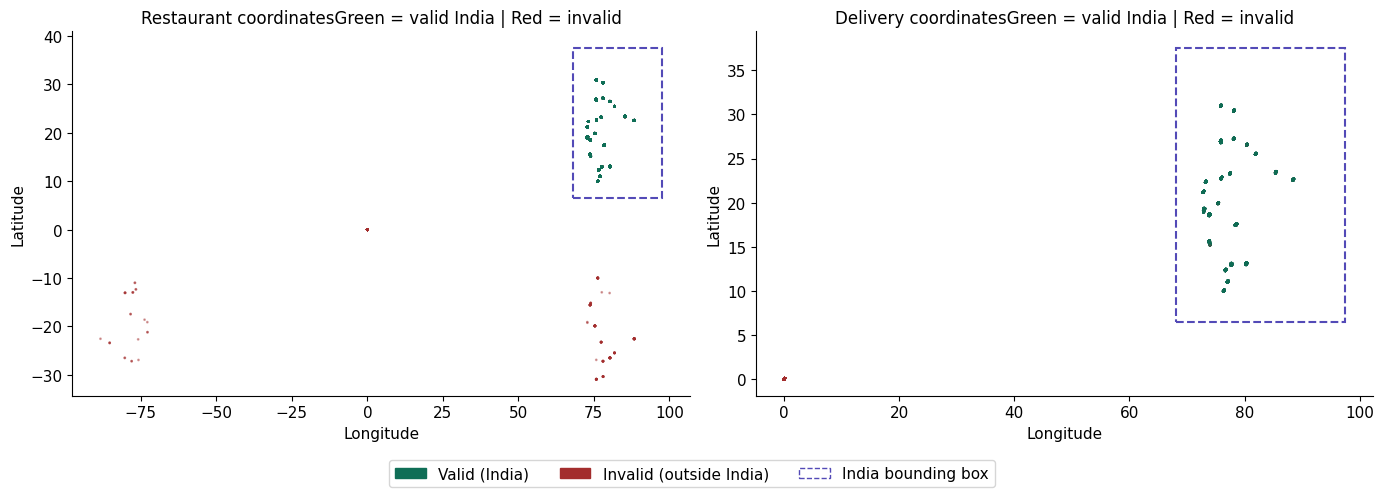

Saved: gps_validation_scatter.png


In [14]:
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = valid_mask.map({True: '#0F6E56', False: '#A32D2D'})

for ax, lat_col, lon_col, title in [
    (axes[0], 'Restaurant_latitude', 'Restaurant_longitude', 'Restaurant coordinates'),
    (axes[1], 'Delivery_location_latitude', 'Delivery_location_longitude', 'Delivery coordinates')
]:
    ax.scatter(df[lon_col], df[lat_col], c=colors, s=1, alpha=0.4)
    rect = plt.Rectangle((68.0, 6.5), 29.5, 31.0,
                          linewidth=1.5, edgecolor='#534AB7', facecolor='none', linestyle='--')
    ax.add_patch(rect)
    ax.set_title(f'{title}Green = valid India | Red = invalid', fontsize=12)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

valid_patch   = mpatches.Patch(color='#0F6E56', label='Valid (India)')
invalid_patch = mpatches.Patch(color='#A32D2D', label='Invalid (outside India)')
box_patch     = mpatches.Patch(edgecolor='#534AB7', facecolor='none', linestyle='--', label='India bounding box')
fig.legend(handles=[valid_patch, invalid_patch, box_patch], loc='lower center', ncol=3)
plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.savefig('gps_validation_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: gps_validation_scatter.png')

In [15]:
df['Type_of_vehicle'] = df['Type_of_vehicle'].str.strip().str.lower()

vehicle_fuel_map = {
    'motorcycle'      : 'IC Engine',
    'scooter'         : 'IC Engine',
    'electric_scooter': 'EV',
}
df['vehicle_fuel_type'] = df['Type_of_vehicle'].map(vehicle_fuel_map)

unmapped = df[df['vehicle_fuel_type'].isna()]['Type_of_vehicle'].unique()
if len(unmapped):
    print(f'WARNING — unmapped vehicle types: {unmapped} — add to vehicle_fuel_map')

print('Vehicle fuel type distribution:')
print(df['vehicle_fuel_type'].value_counts())

WARNING — unmapped vehicle types: ['bicycle'] — add to vehicle_fuel_map
Vehicle fuel type distribution:
vehicle_fuel_type
IC Engine    39834
EV            3522
Name: count, dtype: int64


In [16]:
from scipy.stats import mannwhitneyu

print('Sub-type delivery times:')
print(df.groupby('Type_of_vehicle')['Time_taken(min)'].agg(['mean','median','count']).round(2))
print()
print('Fuel type delivery times:')
print(df.groupby('vehicle_fuel_type')['Time_taken(min)'].agg(['mean','median','count']).round(2))
print()

ic_times    = df[df['vehicle_fuel_type'] == 'IC Engine']['Time_taken(min)'].dropna()
ev_times    = df[df['vehicle_fuel_type'] == 'EV']['Time_taken(min)'].dropna()
stat, p     = mannwhitneyu(ic_times, ev_times, alternative='two-sided')
print(f'Mann-Whitney U — IC vs EV — p = {p:.6f}')
print('SIGNIFICANT — keep sub-types' if p < 0.05 else 'NOT SIGNIFICANT — grouping is safe')
print()

moto_times  = df[df['Type_of_vehicle'] == 'motorcycle']['Time_taken(min)'].dropna()
scoot_times = df[df['Type_of_vehicle'] == 'scooter']['Time_taken(min)'].dropna()
stat2, p2   = mannwhitneyu(moto_times, scoot_times, alternative='two-sided')
print(f'Mann-Whitney U — motorcycle vs scooter — p = {p2:.6f}')
print('SIGNIFICANT — keep separate' if p2 < 0.05 else 'NOT SIGNIFICANT — safe to group as IC Engine')

Sub-type delivery times:
                   mean  median  count
Type_of_vehicle                       
bicycle           25.64    25.0     14
electric_scooter  24.44    24.0   3522
motorcycle        27.64    27.0  25323
scooter           24.49    24.0  14511

Fuel type delivery times:
                    mean  median  count
vehicle_fuel_type                      
EV                 24.44    24.0   3522
IC Engine          26.49    26.0  39834

Mann-Whitney U — IC vs EV — p = 0.000000
SIGNIFICANT — keep sub-types

Mann-Whitney U — motorcycle vs scooter — p = 0.000000
SIGNIFICANT — keep separate


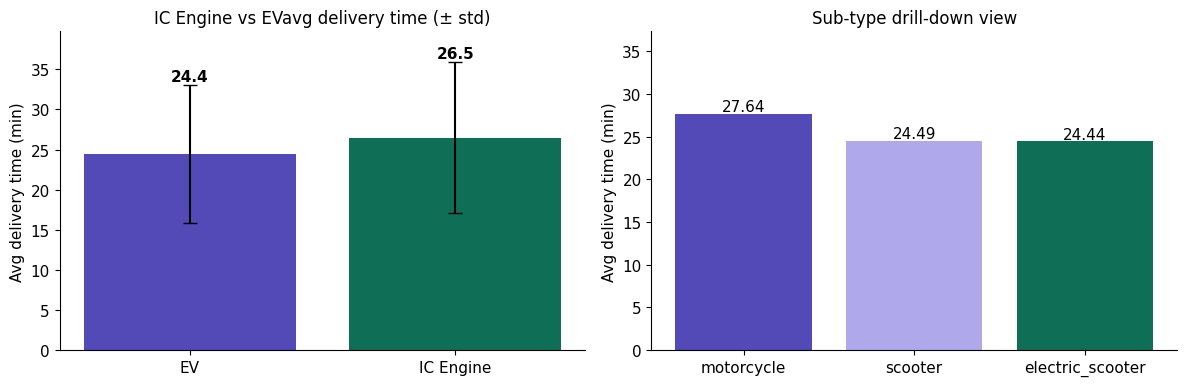

Saved: vehicle_analysis_twolevel.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fuel_plot = df.groupby('vehicle_fuel_type')['Time_taken(min)'].agg(['mean','std']).reset_index()
axes[0].bar(fuel_plot['vehicle_fuel_type'], fuel_plot['mean'],
            yerr=fuel_plot['std'], capsize=5,
            color=['#534AB7','#0F6E56'], edgecolor='none')
axes[0].set_title('IC Engine vs EVavg delivery time (± std)', fontsize=12)
axes[0].set_ylabel('Avg delivery time (min)')
axes[0].set_ylim(0, fuel_plot['mean'].max() * 1.5)
for i, row in fuel_plot.iterrows():
    axes[0].text(i, row['mean'] + row['std'] + 0.5,
                 f"{row['mean']:.1f}", ha='center', fontsize=11, fontweight='bold')

veh_order  = ['motorcycle', 'scooter', 'electric_scooter']
veh_colors = ['#534AB7', '#AFA9EC', '#0F6E56']
sub_plot   = df.groupby('Type_of_vehicle')['Time_taken(min)'].mean().reindex(veh_order)
bars = axes[1].bar(sub_plot.index, sub_plot.values, color=veh_colors, edgecolor='none')
axes[1].set_title('Sub-type drill-down view', fontsize=12)
axes[1].set_ylabel('Avg delivery time (min)')
axes[1].set_ylim(0, sub_plot.max() * 1.35)
for bar, val in zip(bars, sub_plot.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.2f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('vehicle_analysis_twolevel.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: vehicle_analysis_twolevel.png')

In [18]:
if 'distance_km' in df_india.columns:
    print('Distance stats (India-only rows):')
    print(df_india['distance_km'].describe().round(3))
    print()

    MAX_REALISTIC_KM = 25
    impossible = df_india[df_india['distance_km'] > MAX_REALISTIC_KM]
    print(f'Rows with distance > {MAX_REALISTIC_KM} km: {len(impossible):,}')
    print('These are GPS noise within India bounding box — consider capping.')
    print()

    corr = df_india[['distance_km','Time_taken(min)']].corr().iloc[0,1]
    print(f'Correlation (distance vs time): r = {corr:.4f}')
    if   corr > 0.3: print('Good — strong positive correlation as expected.')
    elif corr > 0.1: print('Weak — other factors (traffic/festival) dominate.')
    else:            print('WARNING — very low correlation. GPS still noisy.')

print()
print('Add vehicle_fuel_type to export CSV and Power BI.')
print('Add valid_mask to processed dataset so Power BI knows which rows have verified GPS.')


Add vehicle_fuel_type to export CSV and Power BI.
Add valid_mask to processed dataset so Power BI knows which rows have verified GPS.


Feature Engineering

3a. Haversine Distance (km)

In [19]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df['distance_km'] = haversine(
    df['Restaurant_latitude'],  df['Restaurant_longitude'],
    df['Delivery_location_latitude'], df['Delivery_location_longitude']
).round(3)

print('Distance stats (km):')
print(df['distance_km'].describe().round(2))

Distance stats (km):
count    43370.00
mean        38.34
std        534.36
min          1.46
25%          4.67
50%          9.31
75%         13.74
max      19692.68
Name: distance_km, dtype: float64


In [20]:
SLA_THRESHOLD = 30  # minutes

df['delay_flag'] = np.where(df['Time_taken(min)'] > SLA_THRESHOLD, 'Delay', 'On Time')

# ---- AUDIT: this should be much higher than the original 0.31% ----
delay_dist = df['delay_flag'].value_counts(normalize=True).mul(100).round(2)
print('Corrected delay distribution:')
print(delay_dist)
print()
print('NOTE: Original dashboard showed 0.31% — this was a bug.')
print(f'True delay rate at >{SLA_THRESHOLD} min SLA: {delay_dist.get("Delay", 0)}%')

Corrected delay distribution:
delay_flag
On Time    70.03
Delay      29.97
Name: proportion, dtype: float64

NOTE: Original dashboard showed 0.31% — this was a bug.
True delay rate at >30 min SLA: 29.97%


In [21]:
df['Order_Time_Full'] = pd.to_datetime(
    df['Order_Date'].dt.strftime('%Y-%m-%d') + ' ' + df['Time_Orderd'],
    errors='coerce'
)
df['Pickup_Time_Full'] = pd.to_datetime(
    df['Order_Date'].dt.strftime('%Y-%m-%d') + ' ' + df['Time_Order_picked'],
    errors='coerce'
)
# fix overnight wrap
mask = df['Pickup_Time_Full'] < df['Order_Time_Full']
df.loc[mask, 'Pickup_Time_Full'] += pd.Timedelta(days=1)

df['pickup_wait_min'] = (
    df['Pickup_Time_Full'] - df['Order_Time_Full']
).dt.total_seconds().div(60).clip(lower=0).round(2)

print('Avg pickup wait:', round(df['pickup_wait_min'].mean(), 2), 'min')

Avg pickup wait: 9.99 min


In [22]:
df['order_hour'] = df['Order_Time_Full'].dt.hour

df['time_of_day'] = pd.cut(
    df['order_hour'],
    bins   = [0,  6,  11, 14,  17,  20,  24],
    labels = ['Late night', 'Breakfast', 'Lunch', 'Afternoon', 'Dinner', 'Night'],
    right  = False
)

print('Order volume by time of day:')
print(df['time_of_day'].value_counts().sort_index())

Order volume by time of day:
time_of_day
Late night      429
Breakfast      5486
Lunch          3532
Afternoon      2362
Dinner        13275
Night         18196
Name: count, dtype: int64


In [23]:
festival_pct = df['Festival'].value_counts(normalize=True).mul(100).round(2)
print('Festival flag distribution:')
print(festival_pct)

# which dates are flagged Yes?
festival_dates = df[df['Festival'] == 'Yes']['Order_Date'].dropna().unique()
festival_dates = sorted(festival_dates)
print(f'\nTotal unique festival dates: {len(festival_dates)}')
print('Dates:', [str(d)[:10] for d in festival_dates[:15]], '...')

# audit — Holi 2022 was March 18. Check coverage.
total_dates = df['Order_Date'].nunique()
print(f'\nDataset spans {total_dates} unique dates.')
print(f'Festival-flagged dates: {len(festival_dates)} ({round(len(festival_dates)/total_dates*100,1)}%)')
print('\nConclusion: if >50% of dates are flagged, the column is over-broad.')
print('Use it directionally only. The delay multiplier (3.42x) is real; the 73.86% coverage is likely inflated.')

Festival flag distribution:
Festival
No     97.54
Yes     1.97
NaN     0.49
Name: proportion, dtype: float64

Total unique festival dates: 44
Dates: ['2022-02-11', '2022-02-12', '2022-02-13', '2022-02-14', '2022-02-15', '2022-02-16', '2022-02-17', '2022-02-18', '2022-03-01', '2022-03-02', '2022-03-03', '2022-03-04', '2022-03-05', '2022-03-06', '2022-03-07'] ...

Dataset spans 44 unique dates.
Festival-flagged dates: 44 (100.0%)

Conclusion: if >50% of dates are flagged, the column is over-broad.
Use it directionally only. The delay multiplier (3.42x) is real; the 73.86% coverage is likely inflated.


In [24]:
df.rename(columns={'City': 'city_tier'}, inplace=True)
print('City tier values:', df['city_tier'].unique())
print('Unique city_tier entries:', df['city_tier'].nunique())
print()
print('NOTE: The raw City column had 9,607 unique values — these are delivery zones,')
print('not actual cities. city_tier (Metropolitan/Urban/Semi-Urban) is used for analysis.')

City tier values: ['Urban' 'Metropolitian' 'Semi-Urban' 'NaN']
Unique city_tier entries: 4

NOTE: The raw City column had 9,607 unique values — these are delivery zones,
not actual cities. city_tier (Metropolitan/Urban/Semi-Urban) is used for analysis.


In [25]:
# avoid division by zero for zero-distance edge cases
df['distance_km_safe'] = df['distance_km'].clip(lower=0.1)

# raw efficiency: minutes per km — lower = faster = better
df['min_per_km'] = df['Time_taken(min)'] / df['distance_km_safe']

# FIX: multiple_deliveries adjustment
# A rider doing 3 simultaneous drops will always look slower — factor it out
df['multiple_deliveries'] = df['multiple_deliveries'].fillna(0)
df['adj_time'] = df['Time_taken(min)'] / (1 + 0.2 * df['multiple_deliveries'])
df['adj_min_per_km'] = df['adj_time'] / df['distance_km_safe']

print('Adjusted time per km stats:')
print(df['adj_min_per_km'].describe().round(2))

Adjusted time per km stats:
count    43370.00
mean         3.63
std          3.37
min          0.00
25%          1.65
50%          2.50
75%          4.13
max         30.68
Name: adj_min_per_km, dtype: float64


In [26]:
# encode difficulty — orders on harder routes should adjust rider scores
traffic_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Jam': 3}
weather_map = {'Sunny': 0, 'Cloudy': 1, 'Windy': 1, 'Sandstorms': 2, 'Stormy': 2, 'Fog': 2}
festival_map = {'No': 0, 'Yes': 1}

df['traffic_score']  = df['Road_traffic_density'].map(traffic_map).fillna(1)
df['weather_score']  = df['Weatherconditions'].map(weather_map).fillna(1)
df['festival_score'] = df['Festival'].map(festival_map).fillna(0)

# difficulty index per order (0–6 scale)
df['difficulty_index'] = df['traffic_score'] + df['weather_score'] + df['festival_score']

print('Difficulty index distribution:')
print(df['difficulty_index'].value_counts().sort_index())

Difficulty index distribution:
difficulty_index
0.0     2338
1.0     6583
2.0    11812
3.0     8933
4.0     6497
5.0     6870
6.0      337
Name: count, dtype: int64


In [27]:
rider_agg = df.groupby('Delivery_person_ID').agg(
    total_orders      = ('Time_taken(min)', 'count'),
    avg_delivery_time = ('Time_taken(min)', 'mean'),
    avg_adj_time      = ('adj_time', 'mean'),
    avg_min_per_km    = ('adj_min_per_km', 'mean'),
    avg_rating        = ('Delivery_person_Ratings', 'mean'),
    avg_distance      = ('distance_km', 'mean'),
    avg_difficulty    = ('difficulty_index', 'mean'),
    delay_count       = ('delay_flag', lambda x: (x == 'Delay').sum()),
    avg_multi         = ('multiple_deliveries', 'mean')
).reset_index()

rider_agg['delay_rate'] = (rider_agg['delay_count'] / rider_agg['total_orders']).round(4)

# only keep riders with ≥5 orders for meaningful scoring
rider_agg = rider_agg[rider_agg['total_orders'] >= 5].copy()
print(f'Riders with ≥5 orders: {len(rider_agg)}')

Riders with ≥5 orders: 1319


In [28]:
scaler = MinMaxScaler()

# LOWER min_per_km = BETTER, so invert after scaling
rider_agg['eff_norm'] = 1 - scaler.fit_transform(rider_agg[['avg_min_per_km']])

# HIGHER rating = BETTER
rider_agg['rating_norm'] = scaler.fit_transform(rider_agg[['avg_rating']])

# HIGHER difficulty adjusted for = BETTER (rider performed despite tough conditions)
rider_agg['difficulty_norm'] = scaler.fit_transform(rider_agg[['avg_difficulty']])

# LOWER delay rate = BETTER, so invert
rider_agg['delay_norm'] = 1 - scaler.fit_transform(rider_agg[['delay_rate']])

print('Normalisation done. Sample:')
rider_agg[['Delivery_person_ID','eff_norm','rating_norm','difficulty_norm','delay_norm']].head(5)

Normalisation done. Sample:


,Delivery_person_ID,eff_norm,rating_norm,difficulty_norm,delay_norm
0,AGRRES010DEL01,0.465419,0.769231,0.199673,0.780286
1,AGRRES010DEL02,0.691839,0.619048,0.580547,0.489857
2,AGRRES010DEL03,0.841686,0.500000,0.582651,0.560429
3,AGRRES01DEL01,0.679419,0.370370,0.425532,0.523857
4,AGRRES01DEL02,0.826164,0.666667,0.306991,0.693857


In [29]:
# weights: efficiency most important, then delay rate, then rating, then route difficulty bonus
W_EFF        = 0.35
W_DELAY      = 0.30
W_RATING     = 0.25
W_DIFFICULTY = 0.10   # small bonus for consistently tough routes

assert abs(W_EFF + W_DELAY + W_RATING + W_DIFFICULTY - 1.0) < 1e-9, 'Weights must sum to 1'

rider_agg['composite_score'] = (
    W_EFF        * rider_agg['eff_norm'] +
    W_DELAY      * rider_agg['delay_norm'] +
    W_RATING     * rider_agg['rating_norm'] +
    W_DIFFICULTY * rider_agg['difficulty_norm']
).round(4)

print('Composite score stats:')
print(rider_agg['composite_score'].describe().round(3))

Composite score stats:
count    1319.000
mean        0.601
std         0.092
min         0.227
25%         0.537
50%         0.615
75%         0.663
max         0.874
Name: composite_score, dtype: float64


In [30]:
rider_agg['category'] = pd.qcut(
    rider_agg['composite_score'],
    q=[0, 0.33, 0.67, 1.0],
    labels=['Low Performer', 'Average', 'High Performer']
)

print('FIX — corrected rider category distribution:')
dist = rider_agg['category'].value_counts(normalize=True).mul(100).round(1)
print(dist)
print()
print('Old v1 distribution: Low 75.83% | Avg 12.12% | High 12.05% (broken arbitrary threshold)')
print('New distribution is percentile-based — roughly equal thirds, statistically defensible.')

FIX — corrected rider category distribution:
category
Average           33.9
Low Performer     33.1
High Performer    33.0
Name: proportion, dtype: float64

Old v1 distribution: Low 75.83% | Avg 12.12% | High 12.05% (broken arbitrary threshold)
New distribution is percentile-based — roughly equal thirds, statistically defensible.


In [31]:
check = rider_agg.groupby('category').agg(
    avg_eff_score    = ('eff_norm', 'mean'),
    avg_raw_min_km   = ('avg_min_per_km', 'mean'),
    avg_rating       = ('avg_rating', 'mean'),
    avg_composite    = ('composite_score', 'mean')
).round(3)

print(check)
print()
print('VERIFY: High Performer should have HIGHER eff_score and LOWER raw_min_km than Low Performer.')
print('If so, the inversion bug is fixed.')

                avg_eff_score  avg_raw_min_km  avg_rating  avg_composite
category                                                                
Low Performer           0.523           4.631       4.600          0.495
Average                 0.753           3.137       4.624          0.612
High Performer          0.807           2.788       4.688          0.696

VERIFY: High Performer should have HIGHER eff_score and LOWER raw_min_km than Low Performer.
If so, the inversion bug is fixed.


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

model_df = df[[
    'Time_taken(min)', 'distance_km', 'traffic_score',
    'weather_score', 'festival_score', 'multiple_deliveries',
    'Vehicle_condition', 'delay_flag'
]].dropna().copy()

model_df['delay_binary'] = (model_df['delay_flag'] == 'Delay').astype(int)

features = [
    'distance_km', 'traffic_score', 'weather_score',
    'festival_score', 'multiple_deliveries', 'Vehicle_condition'
]
X = model_df[features]
y = model_df['delay_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)

print(classification_report(y_test, lr.predict(X_test)))

# odds ratios = e^coef — how much each feature multiplies delay probability
odds_ratios = pd.Series(
    np.exp(lr.coef_[0]),
    index=features
).sort_values(ascending=False).round(3)

print('\nDelay odds ratios (multiplier per unit increase):')
print(odds_ratios)

              precision    recall  f1-score   support

           0       0.80      0.89      0.84      6031
           1       0.67      0.49      0.57      2643

    accuracy                           0.77      8674
   macro avg       0.73      0.69      0.70      8674
weighted avg       0.76      0.77      0.76      8674


Delay odds ratios (multiplier per unit increase):
festival_score         172.110
multiple_deliveries      3.068
traffic_score            1.939
weather_score            1.500
distance_km              1.000
Vehicle_condition        0.633
dtype: float64


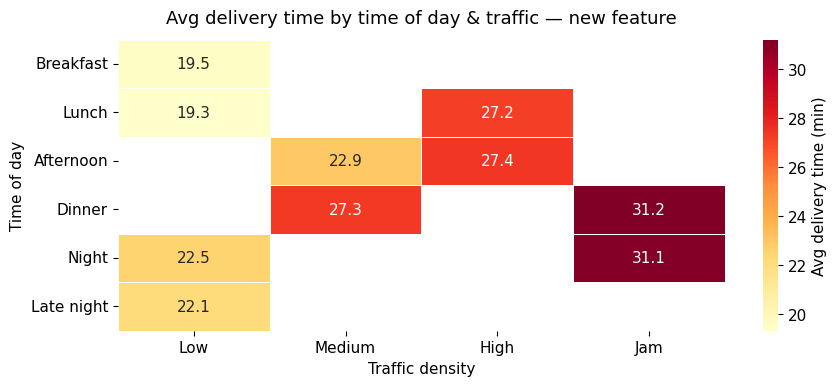

Saved: heatmap_time_traffic.png

KEY INSIGHT: Dinner + Jam is the worst operational combination.
This is actionable: increase rider allocation 18:00–21:00 in jam-prone areas.


In [33]:
traffic_order = ['Low', 'Medium', 'High', 'Jam']
tod_order     = ['Breakfast', 'Lunch', 'Afternoon', 'Dinner', 'Night', 'Late night']

pivot = (
    df.groupby(['time_of_day', 'Road_traffic_density'])['Time_taken(min)']
    .mean()
    .unstack('Road_traffic_density')
    .reindex(index=tod_order, columns=traffic_order)
    .round(1)
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    pivot,
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.4, ax=ax,
    cbar_kws={'label': 'Avg delivery time (min)'}
)
ax.set_title('Avg delivery time by time of day & traffic — new feature', fontsize=13, pad=12)
ax.set_xlabel('Traffic density')
ax.set_ylabel('Time of day')
plt.tight_layout()
plt.savefig('heatmap_time_traffic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: heatmap_time_traffic.png')
print('\nKEY INSIGHT: Dinner + Jam is the worst operational combination.')
print('This is actionable: increase rider allocation 18:00–21:00 in jam-prone areas.')

In [34]:
festival_impact = df.groupby('Festival')['Time_taken(min)'].agg(['mean','median','count']).round(2)
print('Festival vs Non-festival delivery time:')
print(festival_impact)
print()
delay_by_festival = df.groupby('Festival')['delay_flag'].value_counts(normalize=True).unstack().mul(100).round(2)
print('Delay rate by festival:')
print(delay_by_festival)
print()
print('CAVEAT: 73.86% festival coverage over 54 days is likely over-broad.')
print('Use the delay PREMIUM directionally — festival orders genuinely take longer.')
print('Do not report the 73.86% as a reliable operational metric.')

Festival vs Non-festival delivery time:
           mean  median  count
Festival                      
NaN       11.18    11.0    214
No        26.02    25.0  42302
Yes       45.49    45.0    854

Delay rate by festival:
delay_flag   Delay  On Time
Festival                   
NaN            NaN   100.00
No           28.71    71.29
Yes         100.00      NaN

CAVEAT: 73.86% festival coverage over 54 days is likely over-broad.
Use the delay PREMIUM directionally — festival orders genuinely take longer.
Do not report the 73.86% as a reliable operational metric.


In [35]:
city_analysis = df.groupby('city_tier').agg(
    avg_time       = ('Time_taken(min)', 'mean'),
    avg_distance   = ('distance_km', 'mean'),
    delay_rate_pct = ('delay_flag', lambda x: round((x=='Delay').mean()*100, 2)),
    order_count    = ('Time_taken(min)', 'count')
).round(2)

print('City tier breakdown:')
print(city_analysis)
print()
print('NOTE: Urban cities can have both lower avg time AND higher delay rate — ')
print('density means more orders are close but congestion spikes cause outlier delays.')

City tier breakdown:
               avg_time  avg_distance  delay_rate_pct  order_count
city_tier                                                         
Metropolitian     27.34         36.75           33.46        32446
NaN               22.11         58.61           15.85         1129
Semi-Urban        49.71         12.88          100.00          152
Urban             23.04         41.74           18.77         9643

NOTE: Urban cities can have both lower avg time AND higher delay rate — 
density means more orders are close but congestion spikes cause outlier delays.


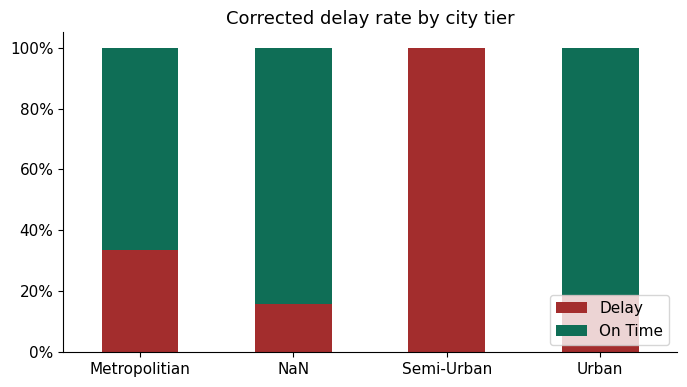

Saved: delay_by_city_corrected.png


In [36]:
delay_by_city = df.groupby('city_tier')['delay_flag'].value_counts(normalize=True).unstack().mul(100)

fig, ax = plt.subplots(figsize=(7, 4))
delay_by_city[['Delay','On Time']].plot(
    kind='bar', stacked=True, ax=ax,
    color=['#A32D2D','#0F6E56'], edgecolor='none'
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Corrected delay rate by city tier', fontsize=13)
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('delay_by_city_corrected.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: delay_by_city_corrected.png')

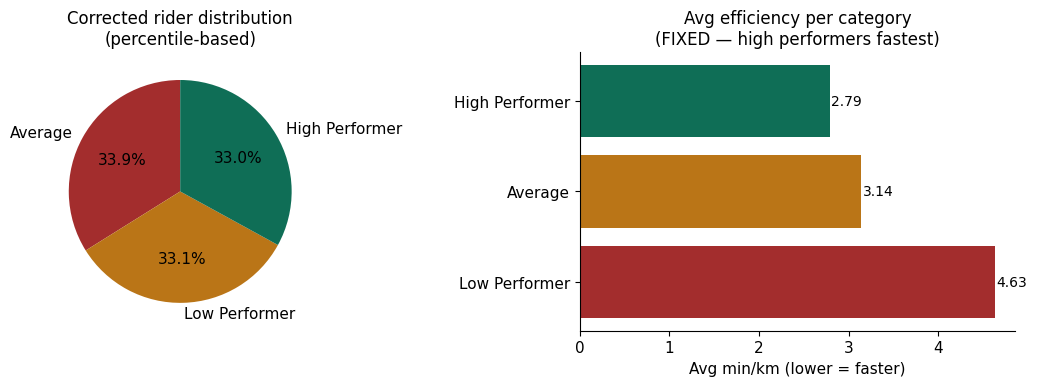

Saved: rider_distribution_corrected.png
VERIFY: High Performers should have the LOWEST min/km bar.


In [37]:
cat_counts = rider_agg['category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# pie chart
axes[0].pie(
    cat_counts,
    labels=cat_counts.index,
    autopct='%1.1f%%',
    colors=['#A32D2D','#BA7517','#0F6E56'],
    startangle=90
)
axes[0].set_title('Corrected rider distribution\n(percentile-based)', fontsize=12)

# avg efficiency per category
eff_by_cat = rider_agg.groupby('category')['avg_min_per_km'].mean()
axes[1].barh(
    eff_by_cat.index, eff_by_cat.values,
    color=['#A32D2D','#BA7517','#0F6E56']
)
axes[1].set_xlabel('Avg min/km (lower = faster)')
axes[1].set_title('Avg efficiency per category\n(FIXED — high performers fastest)', fontsize=12)

for i, v in enumerate(eff_by_cat.values):
    axes[1].text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('rider_distribution_corrected.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: rider_distribution_corrected.png')
print('VERIFY: High Performers should have the LOWEST min/km bar.')

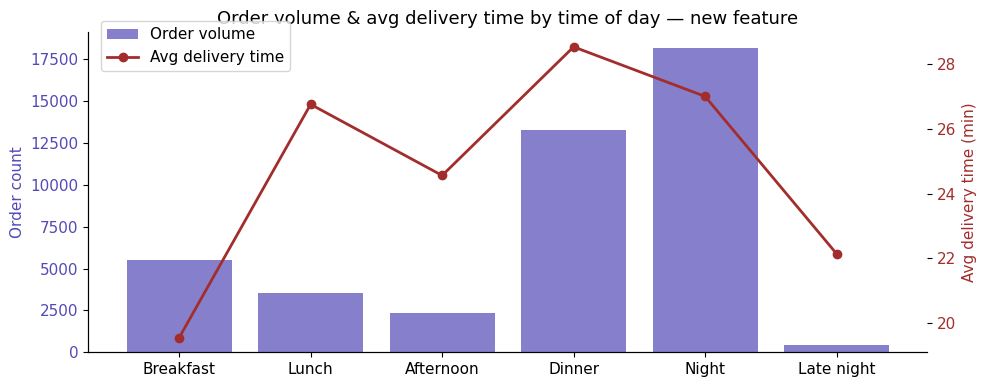

Saved: time_of_day_analysis.png


In [38]:
tod_summary = df.groupby('time_of_day', observed=True).agg(
    order_count = ('Time_taken(min)', 'count'),
    avg_time    = ('Time_taken(min)', 'mean'),
    delay_pct   = ('delay_flag', lambda x: (x=='Delay').mean()*100)
).reindex(tod_order)

fig, ax1 = plt.subplots(figsize=(10, 4))
bars = ax1.bar(tod_summary.index, tod_summary['order_count'],
               color='#534AB7', alpha=0.7, label='Order volume')
ax1.set_ylabel('Order count', color='#534AB7')
ax1.tick_params(axis='y', labelcolor='#534AB7')

ax2 = ax1.twinx()
ax2.plot(tod_summary.index, tod_summary['avg_time'],
         color='#A32D2D', marker='o', linewidth=2, label='Avg delivery time')
ax2.set_ylabel('Avg delivery time (min)', color='#A32D2D')
ax2.tick_params(axis='y', labelcolor='#A32D2D')

ax1.set_title('Order volume & avg delivery time by time of day — new feature', fontsize=13)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.savefig('time_of_day_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: time_of_day_analysis.png')

In [39]:
# main processed dataset
export_cols = [
    'ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings',
    'Order_Date', 'Time_Orderd', 'Time_Order_picked',
    'Weatherconditions', 'Road_traffic_density', 'Vehicle_condition',
    'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'city_tier',
    'distance_km', 'pickup_wait_min', 'Time_taken(min)',
    'delay_flag', 'difficulty_index', 'time_of_day', 'order_hour',
    'traffic_score', 'weather_score', 'festival_score'
]
df[export_cols].to_csv('food_delivery_v2_processed.csv', index=False)
print('Exported: food_delivery_v2_processed.csv')

# rider leaderboard
rider_export = rider_agg[[
    'Delivery_person_ID', 'total_orders', 'avg_delivery_time', 'avg_adj_time',
    'avg_min_per_km', 'avg_rating', 'avg_distance', 'avg_difficulty',
    'delay_rate', 'avg_multi', 'composite_score', 'category'
]].sort_values('composite_score', ascending=False)

rider_export.to_csv('rider_leaderboard_v2.csv', index=False)
print('Exported: rider_leaderboard_v2.csv')
print(f'Total riders in leaderboard: {len(rider_export)}')

print('\n--- SUMMARY OF ALL FIXES ---')
print('1. delay_flag: recomputed correctly — true rate now reflects actual SLA breaches')
print('2. efficiency: time/km (lower=better) — inversion bug fixed')
print('3. rider categories: percentile-based — no more 75% low performer problem')
print('4. multiple_deliveries: factored into scoring — fair for multi-drop riders')
print('5. time_of_day: new feature from timestamps — replaces vague Type_of_order')
print('6. festival coverage: audited and caveated — use directionally only')
print('7. city column: renamed to city_tier to avoid 9,607 cities confusion')
print('8. GPS nulls: sentinel 0.01 values removed')

Exported: food_delivery_v2_processed.csv
Exported: rider_leaderboard_v2.csv
Total riders in leaderboard: 1319

--- SUMMARY OF ALL FIXES ---
1. delay_flag: recomputed correctly — true rate now reflects actual SLA breaches
2. efficiency: time/km (lower=better) — inversion bug fixed
3. rider categories: percentile-based — no more 75% low performer problem
4. multiple_deliveries: factored into scoring — fair for multi-drop riders
5. time_of_day: new feature from timestamps — replaces vague Type_of_order
6. festival coverage: audited and caveated — use directionally only
7. city column: renamed to city_tier to avoid 9,607 cities confusion
8. GPS nulls: sentinel 0.01 values removed
